# Análisis Exploratorio de Datos

### Importación de Módulos

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [49]:
df= pd.read_csv("../data/gen4ou_preview_dataset.csv")
df.head()

,battle_id,p1_poke1,p1_poke2,p1_poke3,p1_poke4,p1_poke5,p1_poke6,p2_poke1,p2_poke2,p2_poke3,p2_poke4,p2_poke5,p2_poke6,p1_win
0,gen4ou-1008776522,Zapdos,Swampert,Breloom,Heatran,Tyranitar,Lucario,Azelf,Starmie,Breloom,Dragonite,Bronzong,Weezing,1
1,gen4ou-1008776522,Azelf,Starmie,Breloom,Dragonite,Bronzong,Weezing,Zapdos,Swampert,Breloom,Heatran,Tyranitar,Lucario,0
2,gen4ou-2360274707,Alakazam,Bronzong,Tyranitar,Starmie,Porygon-Z,Gyarados,Mesprit,Magneton,Milotic,Mismagius,Miltank,Marowak,1
3,gen4ou-2360274707,Mesprit,Magneton,Milotic,Mismagius,Miltank,Marowak,Alakazam,Bronzong,Tyranitar,Starmie,Porygon-Z,Gyarados,0
4,gen4ou-228307929,Mamoswine,Heatran,Shaymin,Suicune,Tyranitar,Dragonite,Metagross,Starmie,Tyranitar,Zapdos,Infernape,Breloom,1


In [50]:
df.shape

df['p1_win'].value_counts(normalize=True)

p1_win
1    0.5
0    0.5
Name: proportion, dtype: float64

## 1. Análisis individual de Pokémon en el metajuego competitivo

### 1.1 Análisis de Frecuencia de Pokémon en el dataset

In [51]:
pokemon_cols = [
    "p1_poke1","p1_poke2","p1_poke3","p1_poke4","p1_poke5","p1_poke6",
    "p2_poke1","p2_poke2","p2_poke3","p2_poke4","p2_poke5","p2_poke6"
]

all_pokemon = pd.concat([df[col] for col in pokemon_cols])

freq = all_pokemon.value_counts()

freq.head(100)

Tyranitar     178986
Jirachi       134292
Heatran       126284
Starmie       124920
Flygon         80658
               ...  
Walrein         1538
Ninjask         1510
Porygon2        1370
Typhlosion      1356
Weezing         1354
Name: count, Length: 100, dtype: int64

In [52]:
freq_percentage = (freq / len(all_pokemon)) * 100
freq_percentage.head(20)

Tyranitar     7.402160
Jirachi       5.553791
Heatran       5.222612
Starmie       5.166202
Flygon        3.335699
Dragonite     3.333383
Breloom       3.318495
Gyarados      3.163906
Infernape     3.081607
Scizor        3.009565
Metagross     2.779377
Zapdos        2.750097
Gengar        2.701876
Swampert      2.583680
Rotom-Wash    2.556881
Latias        2.112138
Skarmory      2.093197
Bronzong      1.959203
Azelf         1.891875
Kingdra       1.826367
Name: count, dtype: float64

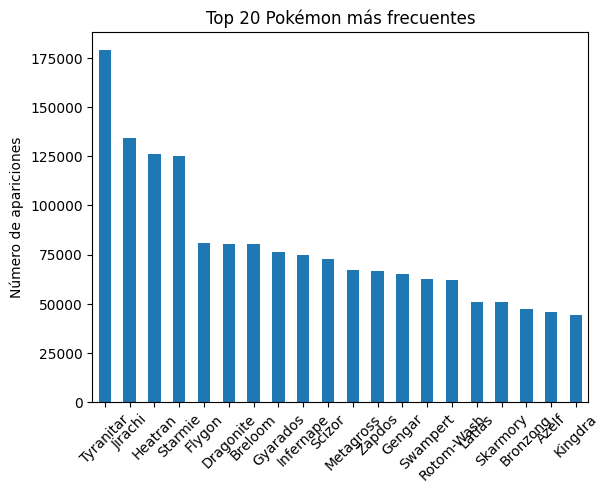

In [53]:
top_20 = freq.head(20)

plt.figure()
top_20.plot(kind="bar")
plt.title("Top 20 Pokémon más frecuentes")
plt.ylabel("Número de apariciones")
plt.xticks(rotation=45)
plt.show()

### 1.2 Análisis de Porcentaje de victorias por Pokémon

In [54]:
df["winning_team"] = df["p1_win"].apply(lambda x: 1 if x == 1 else 2)

records = []

for _, row in df.iterrows():
    
    # Equipo 1
    for col in ["p1_poke1","p1_poke2","p1_poke3","p1_poke4","p1_poke5","p1_poke6"]:
        records.append({
            "pokemon": row[col],
            "win": 1 if row["winning_team"] == 1 else 0
        })
    
    # Equipo 2
    for col in ["p2_poke1","p2_poke2","p2_poke3","p2_poke4","p2_poke5","p2_poke6"]:
        records.append({
            "pokemon": row[col],
            "win": 1 if row["winning_team"] == 2 else 0
        })

long_df = pd.DataFrame(records)

pokemon_stats = (
    long_df
    .groupby("pokemon")
    .agg(
        appearances=("win", "count"),
        wins=("win", "sum")
    )
)

pokemon_stats["winrate"] = pokemon_stats["wins"] / pokemon_stats["appearances"]

pokemon_stats.sort_values("winrate", ascending=False).head(20) 

,appearances,wins,winrate
pokemon,,,
Vibrava,2,2,1.0
Spearow,6,6,1.0
Aron,4,4,1.0
Combusken,8,8,1.0
Wailmer,2,2,1.0
Spoink,2,2,1.0
Skorupi,2,2,1.0
Shellder,2,2,1.0
Seel,4,4,1.0


Aplicamos la Wilson Score Interval para obtener una medida más robusta de la tasa de victorias, especialmente para Pokémon con pocas apariciones. Esto nos permitirá identificar cuáles son los Pokémon más efectivos en combate, teniendo en cuenta tanto su tasa de victorias como la cantidad de veces que han participado en combates.

In [55]:
import numpy as np

def wilson_lower_bound(wins, n, z=1.96):  # 95% confidence
    if n == 0:
        return 0
    p = wins / n
    denominator = 1 + z**2 / n
    centre = p + z**2 / (2*n)
    margin = z * np.sqrt((p*(1-p) + z**2/(4*n)) / n)
    return (centre - margin) / denominator

In [56]:
pokemon_stats["wilson_score"] = pokemon_stats.apply(
    lambda row: wilson_lower_bound(row["wins"], row["appearances"]),
    axis=1
)

pokemon_stats.sort_values("wilson_score", ascending=False).head(20)

,appearances,wins,winrate,wilson_score
pokemon,,,,
Corphish,20,20,1.000000,0.838870
Chimchar,16,16,1.000000,0.806387
Dustox,44,40,0.909091,0.788405
Combusken,8,8,1.000000,0.675584
Vulpix,22,18,0.818182,0.614830
Houndour,6,6,1.000000,0.609657
Sandshrew,6,6,1.000000,0.609657
Spearow,6,6,1.000000,0.609657
Ekans,6,6,1.000000,0.609657


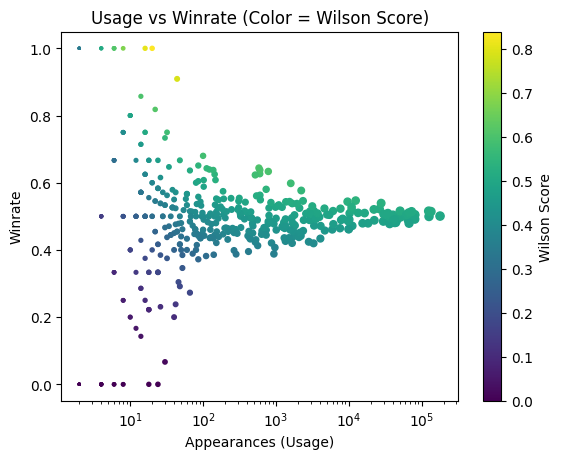

In [57]:
plt.figure()
s= np.log10(pokemon_stats["appearances"]) * 20

plt.scatter(
    pokemon_stats["appearances"],
    pokemon_stats["winrate"],  # tamaño burbuja
    s= s/3,  # tamaño burbuja
    c=pokemon_stats["wilson_score"],     # color
)

plt.colorbar(label="Wilson Score")

plt.xlabel("Appearances (Usage)")
plt.ylabel("Winrate")
plt.xscale("log")
plt.title("Usage vs Winrate (Color = Wilson Score)")

plt.show()

Se observa un patrón de dispersión en forma de embudo, indicativo de alta varianza en muestras pequeñas y convergencia hacia el equilibrio competitivo conforme aumenta el número de apariciones.

A medida que aumentamos el umbral de apariciones, la tasa de victorias de los Pokémon más comunes se vuelve más estable, mientras que los Pokémon con pocas apariciones pueden mostrar tasas de victorias extremas debido a la falta de datos. Con esto podemos establecer que el metajuego (los pokémon más utilizados) está relativamente equilibrado, con una distribución de victorias que no está dominada por un pequeño grupo de Pokémon, aunque algunos destacan por su efectividad.

## 2. Análisis de combinaciones(cores) de Pokémon en el metajuego competitivo

### 2.1 Análisis de combinaciones frecuentes de Pokémon

In [58]:
unique_teams = df.drop_duplicates(subset="battle_id")

In [59]:
teams = []

for _, row in unique_teams.iterrows():
    team1 = [
        row["p1_poke1"], row["p1_poke2"], row["p1_poke3"],
        row["p1_poke4"], row["p1_poke5"], row["p1_poke6"]
    ]
    
    team2 = [
        row["p2_poke1"], row["p2_poke2"], row["p2_poke3"],
        row["p2_poke4"], row["p2_poke5"], row["p2_poke6"]
    ]
    
    teams.append(team1)
    teams.append(team2)

In [60]:
teams = []

for _, row in unique_teams.iterrows():
    team1 = [
        row["p1_poke1"], row["p1_poke2"], row["p1_poke3"],
        row["p1_poke4"], row["p1_poke5"], row["p1_poke6"]
    ]
    
    team2 = [
        row["p2_poke1"], row["p2_poke2"], row["p2_poke3"],
        row["p2_poke4"], row["p2_poke5"], row["p2_poke6"]
    ]
    
    teams.append(team1)
    teams.append(team2)

In [61]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori

te = TransactionEncoder()
te_array = te.fit(teams).transform(teams)

teams_df = pd.DataFrame(te_array, columns=te.columns_)

frequent_itemsets = apriori(
    teams_df,
    min_support=0.02,  # por ejemplo 2% de los equipos
    use_colnames=True
)

frequent_itemsets["size"] = frequent_itemsets["itemsets"].apply(len)
combos = frequent_itemsets[frequent_itemsets["size"] >= 2].copy()
combos["combo"] = combos["itemsets"].apply(lambda x: tuple(sorted(list(x))))
combos["combo"] = combos["itemsets"].apply(lambda x: tuple(sorted(list(x))))
combos.sort_values("support", ascending=False).head(20)

,support,itemsets,size,combo
195,0.166753,"frozenset({Tyranitar, Jirachi})",2,"(Jirachi, Tyranitar)"
234,0.148217,"frozenset({Starmie, Tyranitar})",2,"(Starmie, Tyranitar)"
169,0.114460,"frozenset({Tyranitar, Heatran})",2,"(Heatran, Tyranitar)"
192,0.113612,"frozenset({Starmie, Jirachi})",2,"(Jirachi, Starmie)"
166,0.111259,"frozenset({Starmie, Heatran})",2,"(Heatran, Starmie)"
153,0.106624,"frozenset({Tyranitar, Gyarados})",2,"(Gyarados, Tyranitar)"
79,0.103900,"frozenset({Tyranitar, Breloom})",2,"(Breloom, Tyranitar)"
235,0.096580,"frozenset({Starmie, Zapdos})",2,"(Starmie, Zapdos)"
108,0.096560,"frozenset({Tyranitar, Dragonite})",2,"(Dragonite, Tyranitar)"
154,0.096346,"frozenset({Jirachi, Heatran})",2,"(Heatran, Jirachi)"


#### 2.2 Análisis de winrate de combinaciones frecuentes de Pokémon

In [62]:
unique_df = df.drop_duplicates(subset="battle_id")

teams_data = []

for _, row in unique_df.iterrows():
    
    team1 = {
        "pokemons": set([
            row["p1_poke1"], row["p1_poke2"], row["p1_poke3"],
            row["p1_poke4"], row["p1_poke5"], row["p1_poke6"]
        ]),
        "win": row["p1_win"]
    }
    
    team2 = {
        "pokemons": set([
            row["p2_poke1"], row["p2_poke2"], row["p2_poke3"],
            row["p2_poke4"], row["p2_poke5"], row["p2_poke6"]
        ]),
        "win": 1 - row["p1_win"]
    }
    
    teams_data.append(team1)
    teams_data.append(team2)

In [63]:
def compute_combo_winrate(combo, teams_data):
    total = 0
    wins = 0
    
    combo_set = set(combo)
    
    for team in teams_data:
        if combo_set.issubset(team["pokemons"]):
            total += 1
            wins += team["win"]
    
    if total == 0:
        return 0, 0
    
    return wins / total, total

In [64]:
winrates = []
appearances = []

for combo in combos["itemsets"]:
    wr, total = compute_combo_winrate(combo, teams_data)
    winrates.append(wr)
    appearances.append(total)

combos["combo_winrate"] = winrates
combos["combo_appearances"] = appearances

combos.sort_values("combo_winrate", ascending=False).head(20)

,support,itemsets,size,combo,combo_winrate,combo_appearances
292,0.026446,"frozenset({Starmie, Zapdos, Jirachi, Tyranitar})",4,"(Jirachi, Starmie, Tyranitar, Zapdos)",0.563708,5329
91,0.025206,"frozenset({Tyranitar, Clefable})",2,"(Clefable, Tyranitar)",0.560150,5079
63,0.027702,"frozenset({Starmie, Blissey})",2,"(Blissey, Starmie)",0.559835,5582
281,0.043017,"frozenset({Starmie, Zapdos, Jirachi})",3,"(Jirachi, Starmie, Zapdos)",0.553530,8668
61,0.022303,"frozenset({Blissey, Jirachi})",2,"(Blissey, Jirachi)",0.553182,4494
89,0.031429,"frozenset({Jirachi, Clefable})",2,"(Clefable, Jirachi)",0.549818,6333
289,0.020456,"frozenset({Starmie, Tyranitar, Jirachi, Breloom})",4,"(Breloom, Jirachi, Starmie, Tyranitar)",0.549248,4122
246,0.032188,"frozenset({Starmie, Jirachi, Breloom})",3,"(Breloom, Jirachi, Starmie)",0.545637,6486
172,0.026228,"frozenset({Hippowdon, Starmie})",2,"(Hippowdon, Starmie)",0.545128,5285
231,0.022551,"frozenset({Skarmory, Swampert})",2,"(Skarmory, Swampert)",0.544894,4544


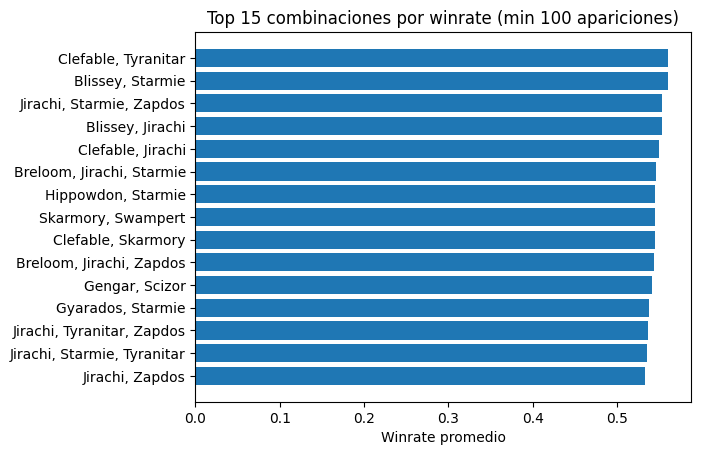

In [65]:
combos_strong = combos[
    (combos["combo_appearances"] > 100) &
    (combos["size"] <= 3)
].copy()


top_combos = combos_strong.sort_values(
    ["combo_winrate", "combo_appearances"],
    ascending=False
).head(15)

plt.figure()

plt.barh(
    top_combos["combo"].str.join(", "),
    top_combos["combo_winrate"]
)

plt.xlabel("Winrate promedio")
plt.title("Top 15 combinaciones por winrate (min 100 apariciones)")
plt.gca().invert_yaxis()

plt.show()

#### 2.3 Análisis de Pokémon más comunes en combinaciones más efectivas

In [66]:
winning_combos = combos[
    (combos["combo_winrate"] > 0.52) &
    (combos["combo_appearances"] > 100)
]

from collections import Counter

pokemon_counter = Counter()

for combo in winning_combos["itemsets"]:
    for poke in combo:
        pokemon_counter[poke] += 1

participation_df = pd.DataFrame.from_dict(
    pokemon_counter,
    orient="index",
    columns=["winning_combo_count"]
)

participation_df = participation_df.sort_values(
    "winning_combo_count",
    ascending=False
)

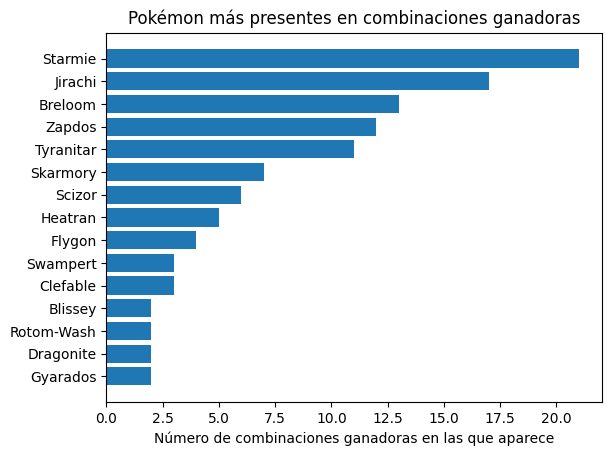

In [67]:
top_participants = participation_df.head(15)

plt.figure()

plt.barh(
    top_participants.index,
    top_participants["winning_combo_count"]
)

plt.xlabel("Número de combinaciones ganadoras en las que aparece")
plt.title("Pokémon más presentes en combinaciones ganadoras")
plt.gca().invert_yaxis()

plt.show()

Aunque individualmente presentan winrate cercano al equilibrio, ciertos Pokémon destacan por su alta participación en combinaciones estructuralmente ganadoras, lo que sugiere que su valor estratégico puede ser mayor cuando se consideran sinergias con otros Pokémon. Esto resalta la importancia de analizar no solo el rendimiento individual, sino también cómo los Pokémon interactúan en equipo para maximizar su efectividad en combate.

#### 2.4 Análisis de Synergy Winrate Gap

Definimos el Synergy Winrate Gap como la diferencia entre el winrate promedio de un pokémon en combinaciones  y su winrate individual. Este análisis nos permite identificar qué pokémon se benefician más de las sinergias en equipo, lo que puede ser crucial para la construcción de equipos efectivos en el metajuego competitivo. Un Synergy Winrate Gap positivo indica que un pokémon tiene un rendimiento significativamente mejor cuando se combina con ciertos compañeros, mientras que un gap negativo sugiere que el pokémon no se beneficia tanto de las sinergias y podría ser más efectivo por sí solo o con diferentes compañeros.

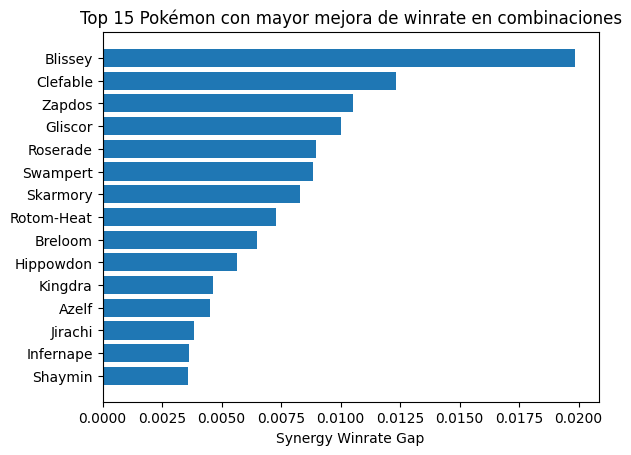

In [68]:
strong_combos = combos[
    (combos["combo_appearances"] > 100)
]

from collections import defaultdict
import numpy as np

combo_winrate_accumulator = defaultdict(list)

for _, row in strong_combos.iterrows():
    combo = row["itemsets"]
    wr = row["combo_winrate"]
    
    for poke in combo:
        combo_winrate_accumulator[poke].append(wr)

synergy_data = []

for poke, wr_list in combo_winrate_accumulator.items():
    synergy_data.append({
        "pokemon": poke,
        "combo_avg_winrate": np.mean(wr_list),
        "combo_count": len(wr_list)
    })

synergy_df = pd.DataFrame(synergy_data)

synergy_df = synergy_df.merge(
    pokemon_stats[["winrate"]],
    left_on="pokemon",
    right_index=True
)

synergy_df["synergy_winrate_gap"] = (
    synergy_df["combo_avg_winrate"] -
    synergy_df["winrate"]
)


top_synergy = synergy_df.sort_values(
    "synergy_winrate_gap",
    ascending=False
).head(15)

plt.figure()

plt.barh(
    top_synergy["pokemon"],
    top_synergy["synergy_winrate_gap"]
)

plt.xlabel("Synergy Winrate Gap")
plt.title("Top 15 Pokémon con mayor mejora de winrate en combinaciones")
plt.gca().invert_yaxis()

plt.show()

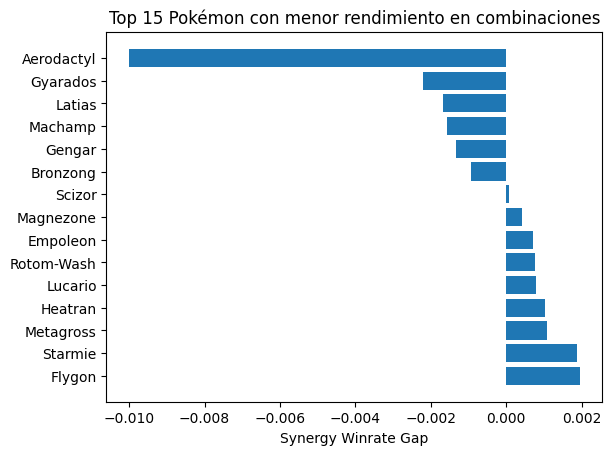

In [69]:
negative_synergy = synergy_df.sort_values(
    "synergy_winrate_gap",
    ascending=True
).head(15)

plt.figure()

plt.barh(
    negative_synergy["pokemon"],
    negative_synergy["synergy_winrate_gap"]
)

plt.xlabel("Synergy Winrate Gap")
plt.title("Top 15 Pokémon con menor rendimiento en combinaciones")
plt.gca().invert_yaxis()

plt.show()

## 3. Detección de datos perdidos y outliers

### 3.1 Detección de equipos incompletos

In [70]:
p1_cols = [f"p1_poke{i}" for i in range(1, 7)]
p2_cols = [f"p2_poke{i}" for i in range(1, 7)]

invalid_size_p1 = df[df[p1_cols].isnull().any(axis=1)]
invalid_size_p2 = df[df[p2_cols].isnull().any(axis=1)]

invalid_size_p1 += df[(df[p1_cols] == "").any(axis=1)]
invalid_size_p2 += df[(df[p2_cols] == "").any(axis=1)]

print(f"Equipos con tamaño inválido en p1: {len(invalid_size_p1)}")
print(f"Equipos con tamaño inválido en p2: {len(invalid_size_p2)}")


Equipos con tamaño inválido en p1: 0
Equipos con tamaño inválido en p2: 0


### 3.2 Detección de outliers 

#### 3.2.1 Detección Pokémon duplicados en el mismo equipo

In [71]:
def has_duplicates(row, cols):
    team = row[cols].tolist()
    return len(team) != len(set(team))

dup_p1 = df[df.apply(lambda row: has_duplicates(row, p1_cols), axis=1)]
dup_p2 = df[df.apply(lambda row: has_duplicates(row, p2_cols), axis=1)]

In [72]:
print(f"Equipos con Pokémon duplicados en p1: {len(dup_p1)}")
print(f"Equipos con Pokémon duplicados en p2: {len(dup_p2)}")

Equipos con Pokémon duplicados en p1: 0
Equipos con Pokémon duplicados en p2: 0


#### 3.2.2 Detección de Pokémon no reconocidos

In [73]:
pokemon_stats = pd.read_csv("../data/OUStats.csv")
valid_set = set(pokemon_stats["Name"])

In [74]:
all_pokemon_dataset = set(
    df[p1_cols + p2_cols].values.flatten()
)

unknown_pokemon = all_pokemon_dataset - valid_set
print(f"Pokémon no reconocidos en el dataset: {unknown_pokemon}")

Pokémon no reconocidos en el dataset: {'Deoxys-Speed', 'Shaymin', 'Shaymin-Sky', 'Pichu-Spiky-eared', 'Giratina-Origin', 'Giratina', 'Farfetch’d', 'Nidoran-F', 'Arceus-Fighting'}


#### 3.2.3 Tratamiento de Pokémon no reconocidos

In [77]:
manual_mapping = {
    "Deoxys-Speed": "DeoxysSpeedSpeed",
    "Shaymin": "ShayminLandLand",
    "Shaymin-Sky": "Shaymin-SkySkySky",
    "Pichu-Spiky-eared": "Pichu",
    "Giratina-Origin": "GiratinaOriginOrigin",
    "Giratina": "GiratinaAlteredAltered",
    "Farfetch’d": "Farfetch'd"
}

poke_cols = p1_cols + p2_cols

df_cleaned = df.copy()
df_cleaned[poke_cols] = df_cleaned[poke_cols].replace(manual_mapping)

#guarda el dataset limpio para futuras etapas
df_cleaned.to_csv("../data/gen4ou_cleaned_dataset.csv", index=False)

Se realiza un mapeo manual de los nombres no reconocidos a sus equivalentes correctos en el dataset de estadísticas de Pokémon. Se mantienen los nombres de Nidoran-F y Arceus-Fighting, ya que no son problemas de nombrado, y se tratarán más adelante cuando se añadan las variables derivadas.